In [29]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# load from joblib

df = joblib.load('df.joblib')
df

,Price,Bedrooms,Locality,Is_premium_subarea,Property_type,Area,Is_estate,Price_log,Group_median,Group_std,Price_zscore_in_group
0,400000,1,ajah,0,mini flat,island,1,12.899222,365000.0,1.204600e+06,0.029055
1,14000000,3,ikoyi,1,flat,island,0,16.454568,7500000.0,5.588542e+06,1.163094
2,200000,1,yaba,0,mini flat,mainland,0,12.206078,350000.0,1.978814e+05,-0.758030
3,800000,2,surulere,0,flat,mainland,0,13.592368,725000.0,3.662361e+05,0.204786
4,300000,1,yaba,0,mini flat,mainland,0,12.611541,350000.0,1.978814e+05,-0.252677
...,...,...,...,...,...,...,...,...,...,...,...
8805,2000000,4,odofin,0,duplex,mainland,0,14.508658,1500000.0,3.231787e+05,1.547132
8811,2500000,4,gbagada,0,house,mainland,0,14.731802,2500000.0,1.000000e+00,0.000000
8812,900000,2,ogudu,1,flat,mainland,0,13.710151,1000000.0,4.179620e+05,-0.239256
8813,3600000,1,ilupeju,0,mini flat,mainland,0,15.096445,400000.0,7.369032e+05,4.342497


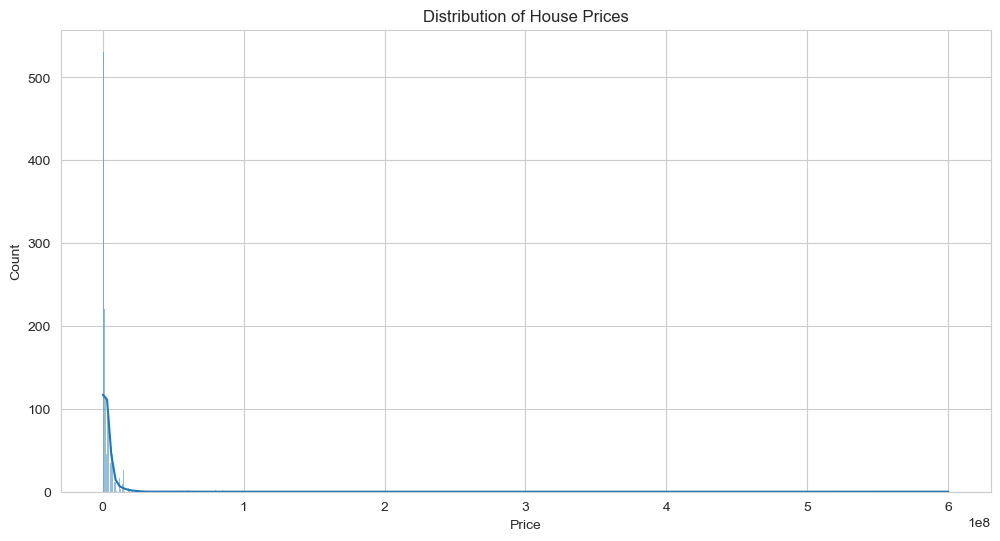

In [109]:
#Price Distribution

sns.histplot(df['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

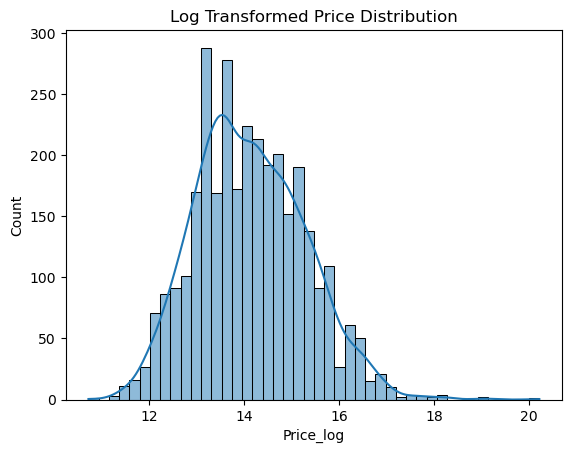

In [33]:
#Log Transform for Skewed Prices

#Housing prices are usually heavily skewed.

df['Price_log'] = np.log1p(df['Price'])

sns.histplot(df['Price_log'], kde=True)
plt.title('Log Transformed Price Distribution')
plt.show()

GROUP_MEDIAN AND GROUP_STD WILL BE DROPPED, THE ARE CORRELATED AND ALSO CAN CAUSE DATA LEAKAGE WHEN 'PRICE' IS THE DATA


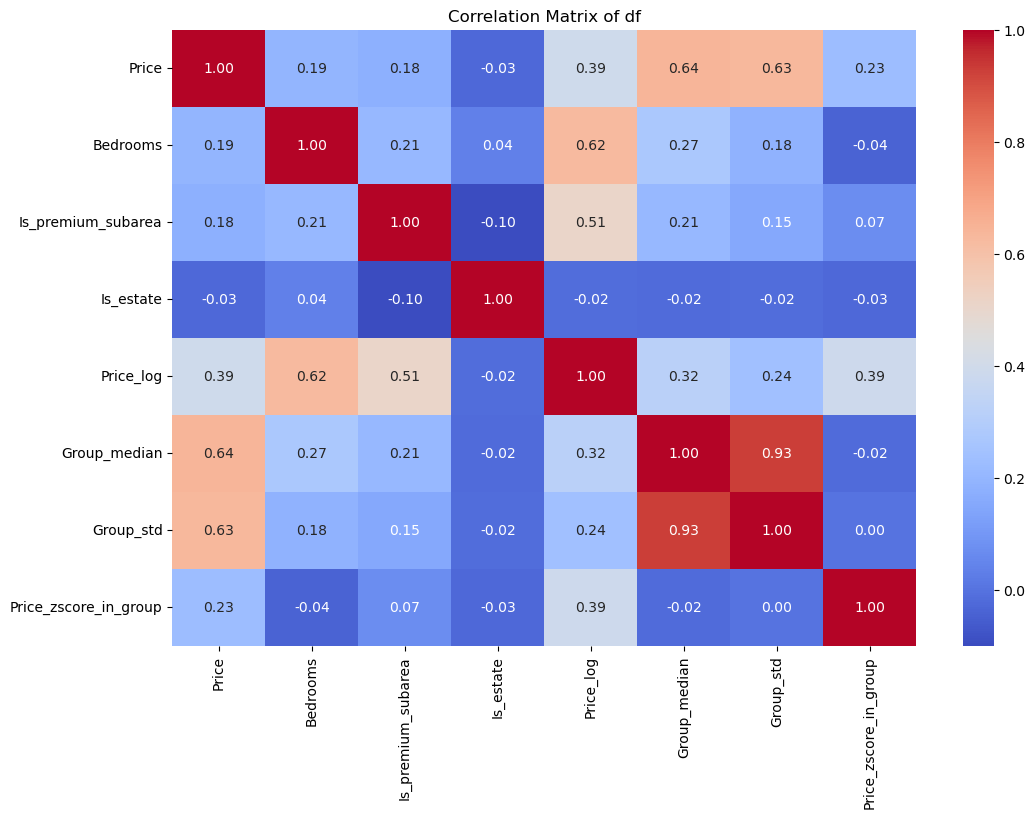

In [37]:
#Correlation Heatmap
print("GROUP_MEDIAN AND GROUP_STD WILL BE DROPPED, THE ARE CORRELATED AND ALSO CAN CAUSE DATA LEAKAGE WHEN 'PRICE' IS THE DATA")
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix of df')
plt.show()

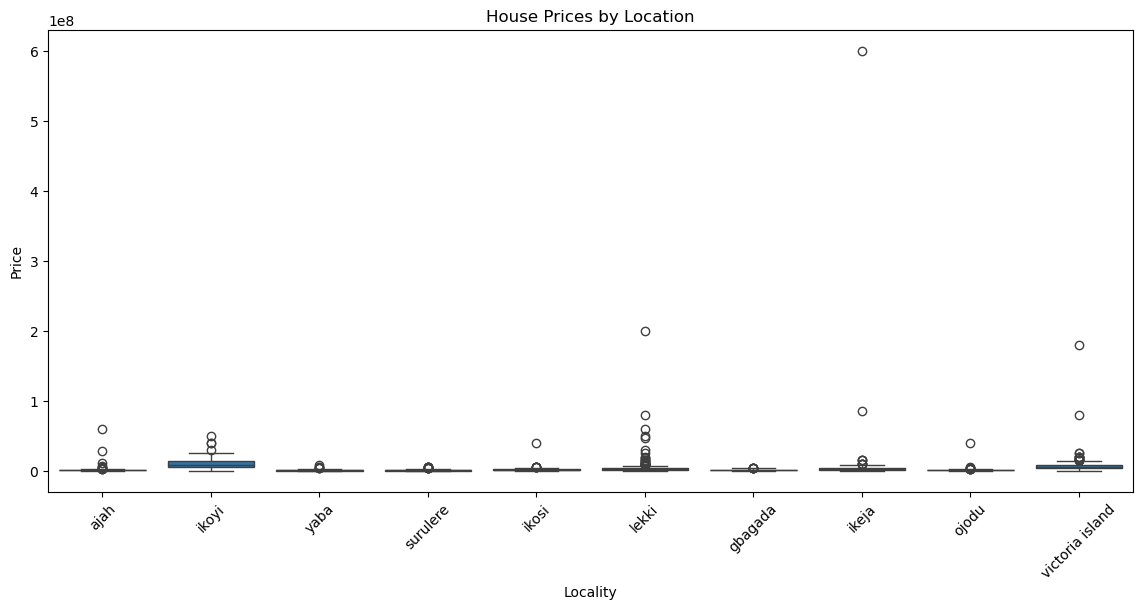

In [41]:
#Price by Location

top_locations = df['Locality'].value_counts().head(10).index

filtered = df[df['Locality'].isin(top_locations)]

plt.figure(figsize=(14,6))

sns.boxplot(data=filtered,
            x='Locality',
            y='Price')

plt.xticks(rotation=45)
plt.title('House Prices by Location')
plt.show()

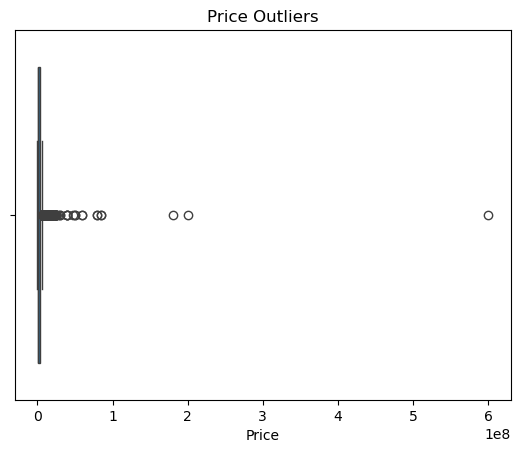

In [43]:
#Outlier Detection in price

sns.boxplot(x=df['Price'])
plt.title('Price Outliers')
plt.show()

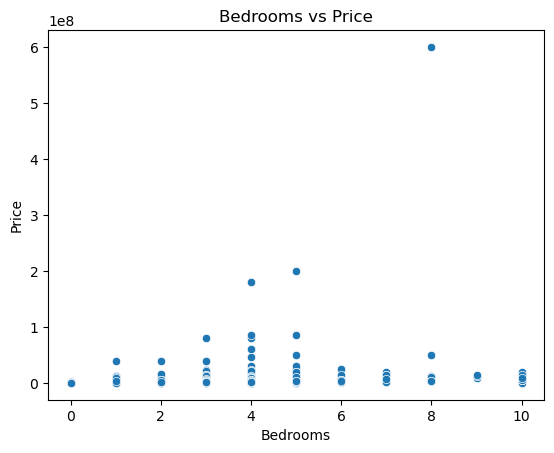

In [49]:
#Bedrooms vs Price

sns.scatterplot(data=df,
                x='Bedrooms',
                y='Price')

plt.title('Bedrooms vs Price')
plt.show()

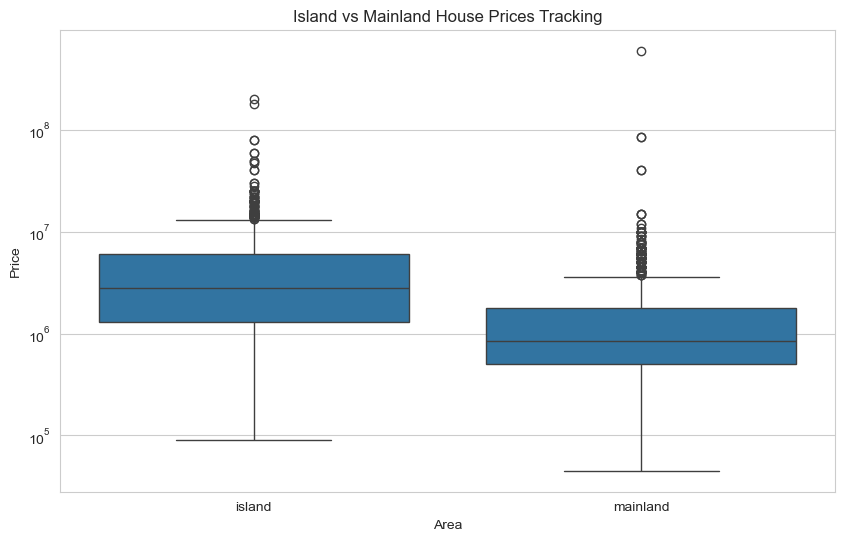

In [67]:
# Island vs Mainland Comparison

plt.figure(figsize=(10,6))

sns.boxplot(data=df,
            x='Area',
            y='Price')

plt.yscale('log')
plt.title('Island vs Mainland House Prices Tracking')
plt.show()

In [83]:
# Average Prices by Area

print("""
    Expected Insights:
    - Island properties are generally more expensive.
    - Mainland areas may show higher affordability.
    - Large spread indicates luxury property concentration on the island.
    """)

area_summary = df.groupby('Area')['Price'].agg(['mean', 'median', 'count'])
print(area_summary)


    Expected Insights:
    - Island properties are generally more expensive.
    - Mainland areas may show higher affordability.
    - Large spread indicates luxury property concentration on the island.
    
                  mean     median  count
Area                                    
island    5.324563e+06  2800000.0   1103
mainland  1.879449e+06   850000.0   2093


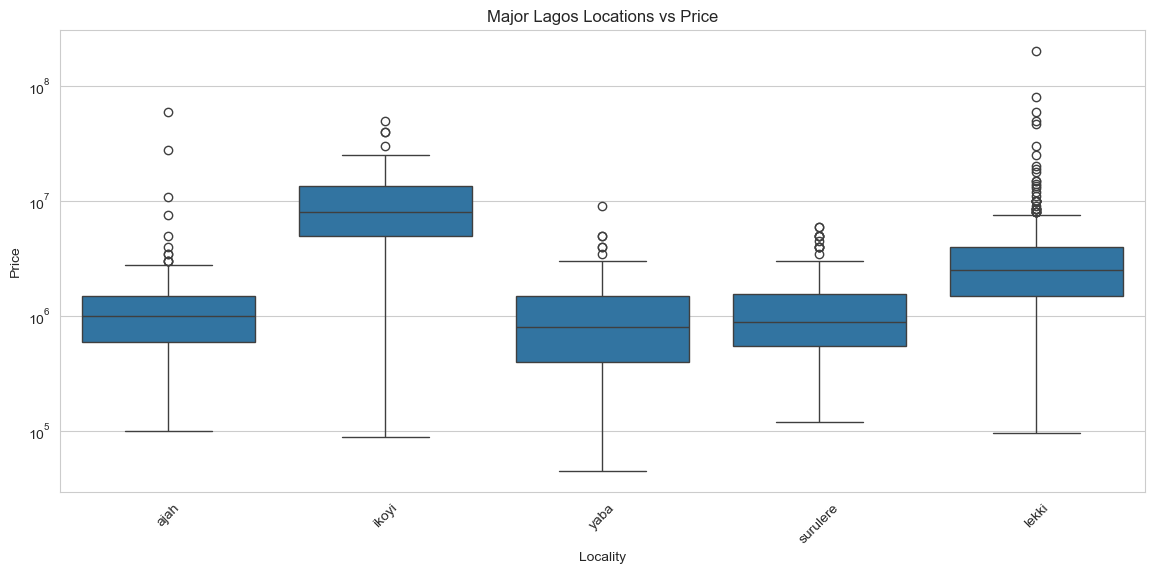

In [85]:
#Lekki vs Ikoyi vs Yaba vs Surulere vs Ajah
#Top Lagos localities comparison.

major_locations = ['lekki', 'ikoyi', 'ajah', 'yaba', 'surulere']

filtered = df[df['Locality'].isin(major_locations)]

plt.figure(figsize=(14,6))

sns.boxplot(data=filtered,
            x='Locality',
            y='Price')

plt.yscale('log')
plt.title('Major Lagos Locations vs Price')
plt.xticks(rotation=45)
plt.show()

In [87]:
location_rank = (
    filtered
    .groupby('Locality')['Price']
    .median()
    .sort_values(ascending=False)
)

print(location_rank)

Locality
ikoyi       8000000.0
lekki       2500000.0
ajah        1000000.0
surulere     900000.0
yaba         800000.0
Name: Price, dtype: float64


In [93]:
premium_summary = (
    df.groupby('Is_premium_subarea')['Price']
      .agg(['mean', 'median', 'count'])
)

print(premium_summary)

                            mean     median  count
Is_premium_subarea                                
0                   1.590551e+06   850000.0   2234
1                   6.500403e+06  3500000.0    962


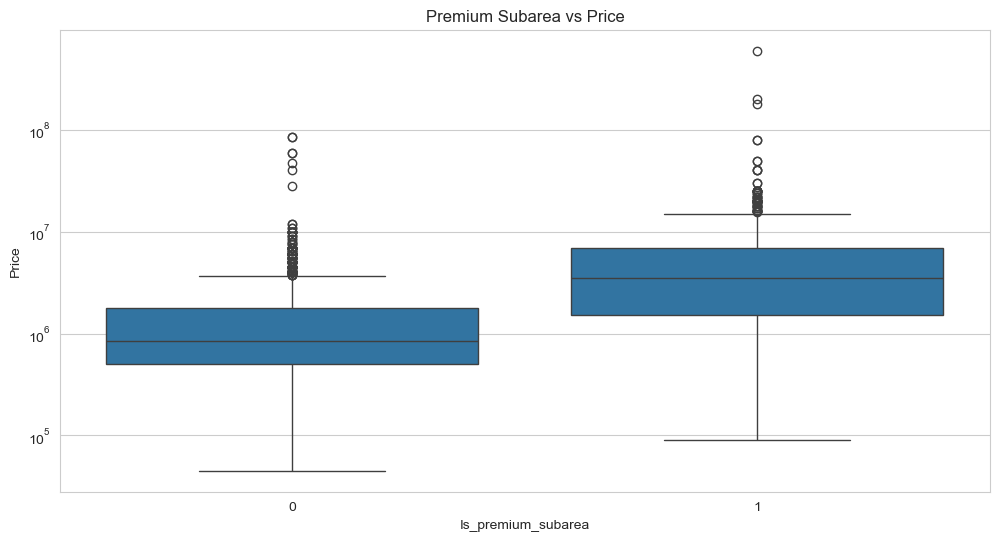

In [95]:
sns.boxplot(data=df,
            x='Is_premium_subarea',
            y='Price')

plt.yscale('log')
plt.title('Premium Subarea vs Price')
plt.show()

In [97]:
# Property Type Analysis

property_summary = (
    df.groupby('Property_type')['Price']
      .median()
      .sort_values(ascending=False)
)

print(property_summary)

Property_type
house           4000000.0
duplex          3000000.0
bungalow        1000000.0
flat             900000.0
mini flat        450000.0
self contain     230000.0
Name: Price, dtype: float64


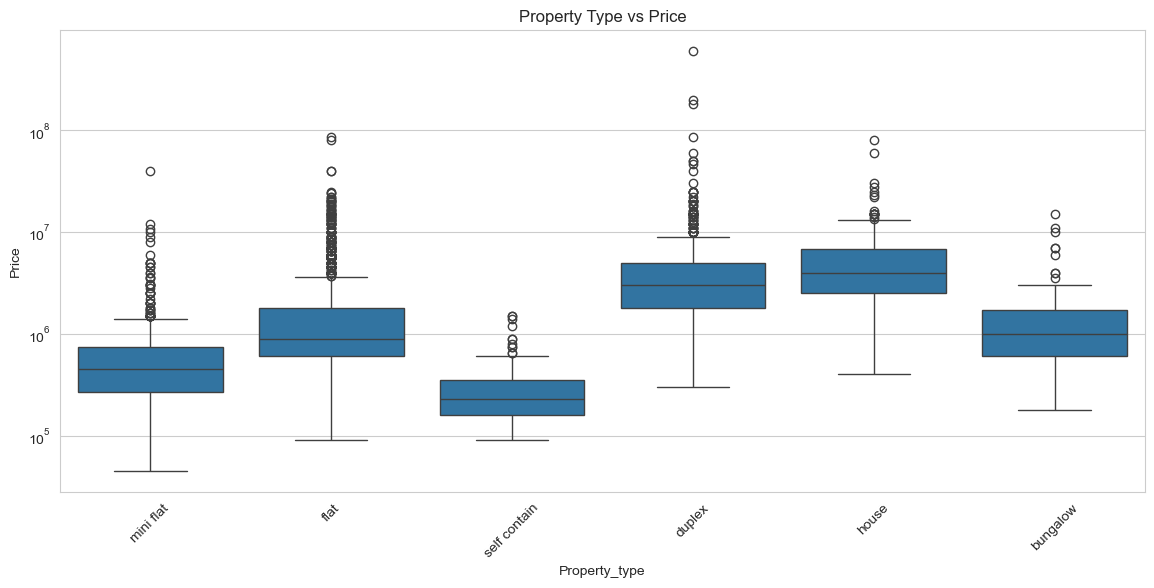

In [99]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df,
            x='Property_type',
            y='Price')

plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Property Type vs Price')
plt.show()

In [101]:
# Cheapest and Most Expensive Localities

locality_prices = (
    df.groupby('Locality')['Price']
      .median()
      .sort_values()
)

print(locality_prices.head(10))
print(locality_prices.tail(10))

Locality
ojo         225000.0
badagry     255000.0
ejigbo      300000.0
ipaja       320000.0
ikorodu     320000.0
mushin      350000.0
igando      350000.0
orile       375000.0
idimu       400000.0
alimosho    400000.0
Name: Price, dtype: float64
Locality
gbagada            1200000.0
ikosi              1300000.0
apapa              1400000.0
ilupeju            1500000.0
ketu               1500000.0
maryland           2000000.0
ikeja              2500000.0
lekki              2500000.0
victoria island    5000000.0
ikoyi              8000000.0
Name: Price, dtype: float64


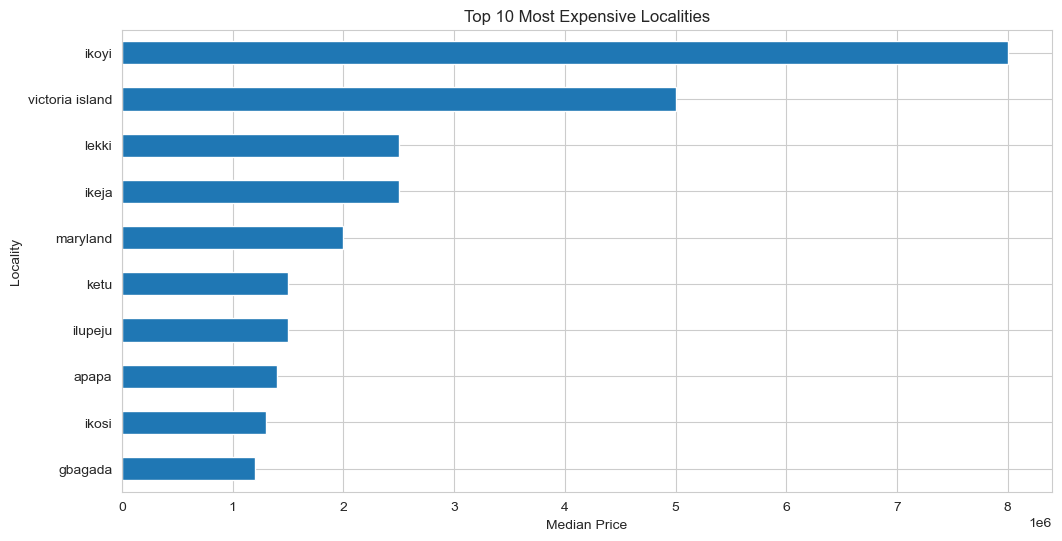

In [103]:
top10 = locality_prices.tail(10)

plt.figure(figsize=(12,6))

top10.plot(kind='barh')
plt.title('Top 10 Most Expensive Localities')
plt.xlabel('Median Price')
plt.show()

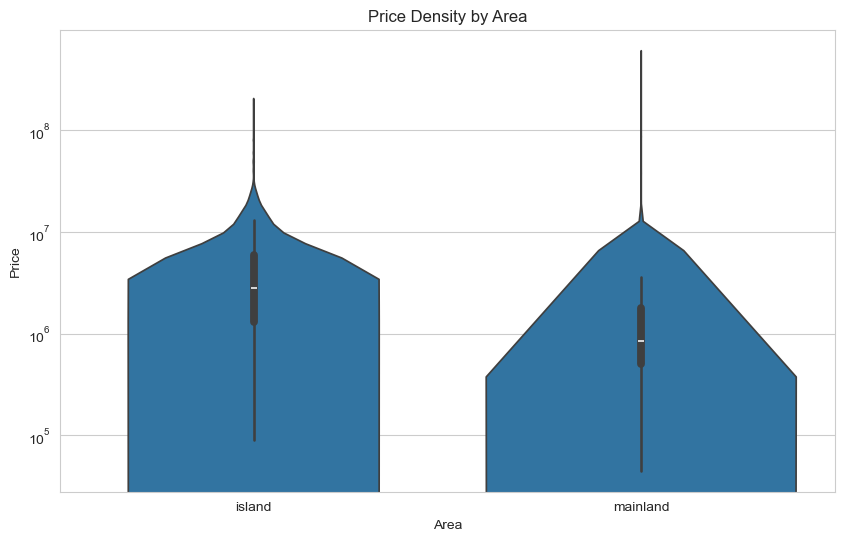

In [111]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Area',
    y='Price'
)

plt.yscale('log')

plt.title('Price Density by Area')
plt.xlabel('Area')
plt.ylabel('Price')

plt.show()

In [115]:
bedroom_location = pd.crosstab(
    df['Locality'],
    df['Bedrooms']
)

print(bedroom_location)

Bedrooms         0   1   2    3    4   5   6   7   8   9   10
Locality                                                     
agege             2   2   5   18    2   1   0   0   0   0   0
ajah             11  24  42   64   47  16   2   1   0   0   0
alimosho          3   9  18   23    6   1   2   0   0   0   0
apapa             0   0   6    7    1   0   1   0   0   0   0
badagry           0   4   3    2    1   0   0   0   0   0   0
berger            0   0   2    0    0   0   0   0   0   0   0
egba              1   4  12   24    3   0   0   0   0   0   0
ejigbo            1   1   3    2    0   0   0   0   0   0   0
gbagada           3  19  30   43   23  15   4   2   0   0   0
idimu             0   3   4    4    0   0   0   0   0   0   0
igando            0   2   5    8    2   0   0   0   0   0   0
ikeja             1  31  32   82   50  44   9   9   4   0   2
ikorodu           1  11  23   17    5   2   0   0   0   0   0
ikosi             2  17  36   57   30  22   5   0   0   0   0
ikoyi   

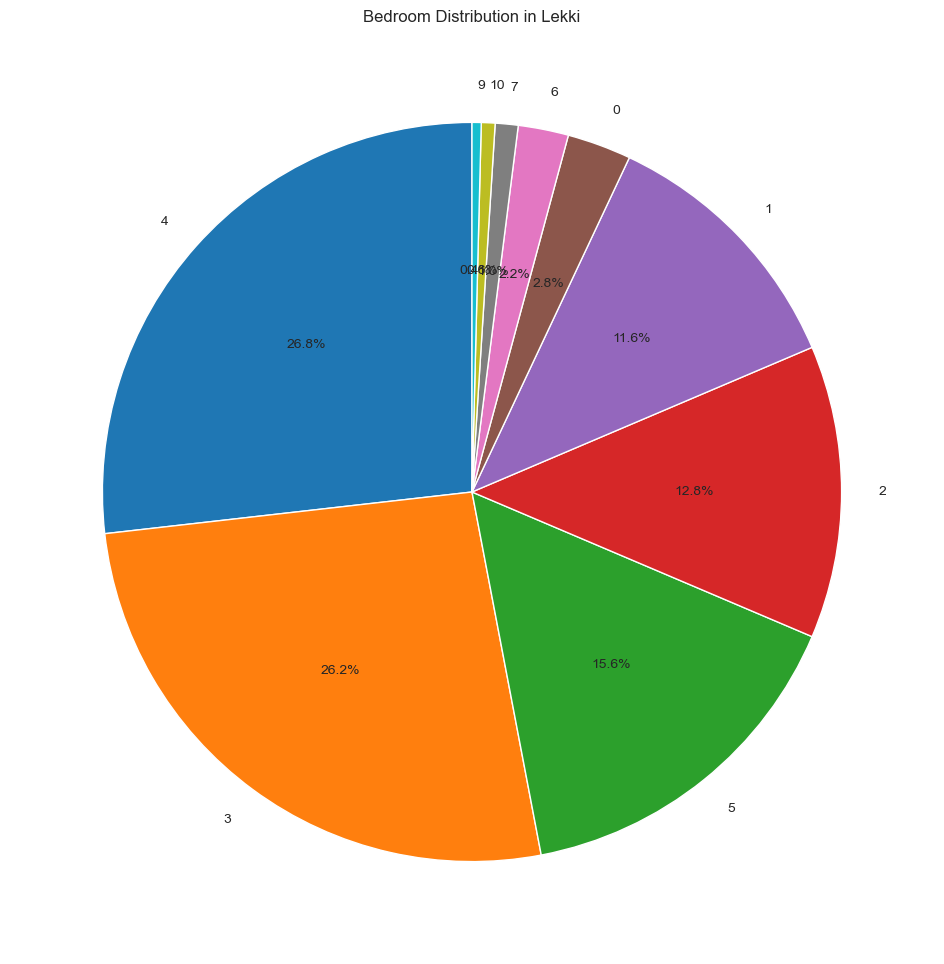

In [123]:
lekki_data = df[df['Locality'] == 'lekki']

bedroom_counts = lekki_data['Bedrooms'].value_counts()

plt.figure(figsize=(16,12))

plt.pie(
    bedroom_counts,
    labels=bedroom_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Bedroom Distribution in Lekki')
plt.show()

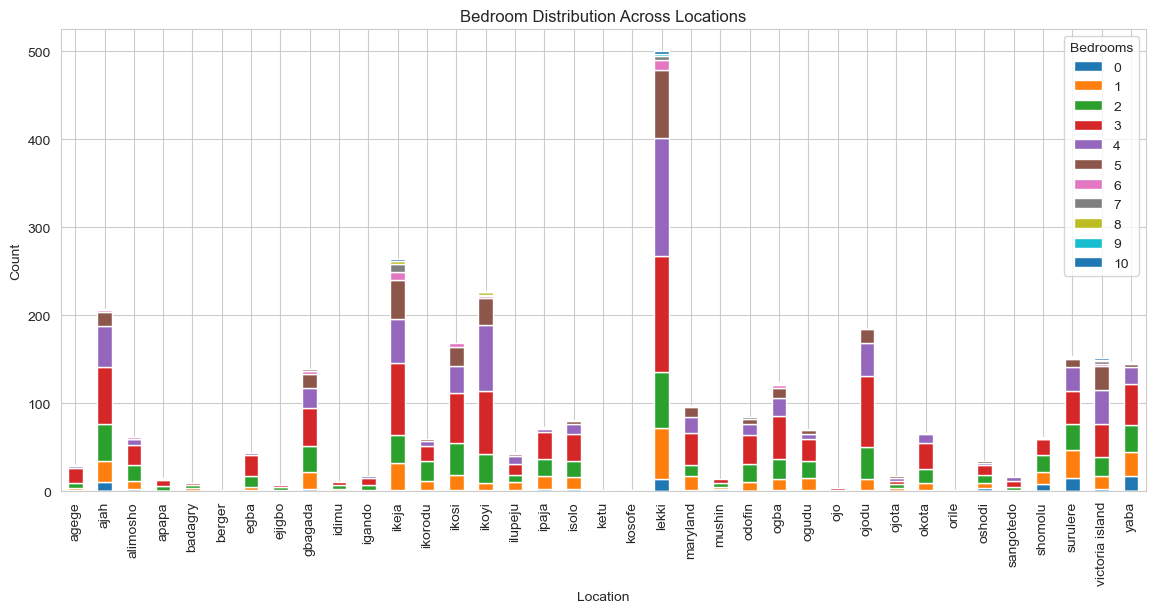

In [125]:
bedroom_location = pd.crosstab(
    df['Locality'],
    df['Bedrooms']
)

bedroom_location.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title('Bedroom Distribution Across Locations')
plt.xlabel('Location')
plt.ylabel('Count')

plt.show()

In [129]:
locality_property = pd.crosstab(
    df['Locality'],
    df['Property_type']
)

print(locality_property.head())

Property_type  bungalow  duplex  flat  house  mini flat  self contain
Locality                                                             
agege                 3       2    21      0          2             2
ajah                 19      49    87     17         24            11
alimosho              1       7    42      0          9             3
apapa                 0       3    12      0          0             0
badagry               1       0     5      0          4             0


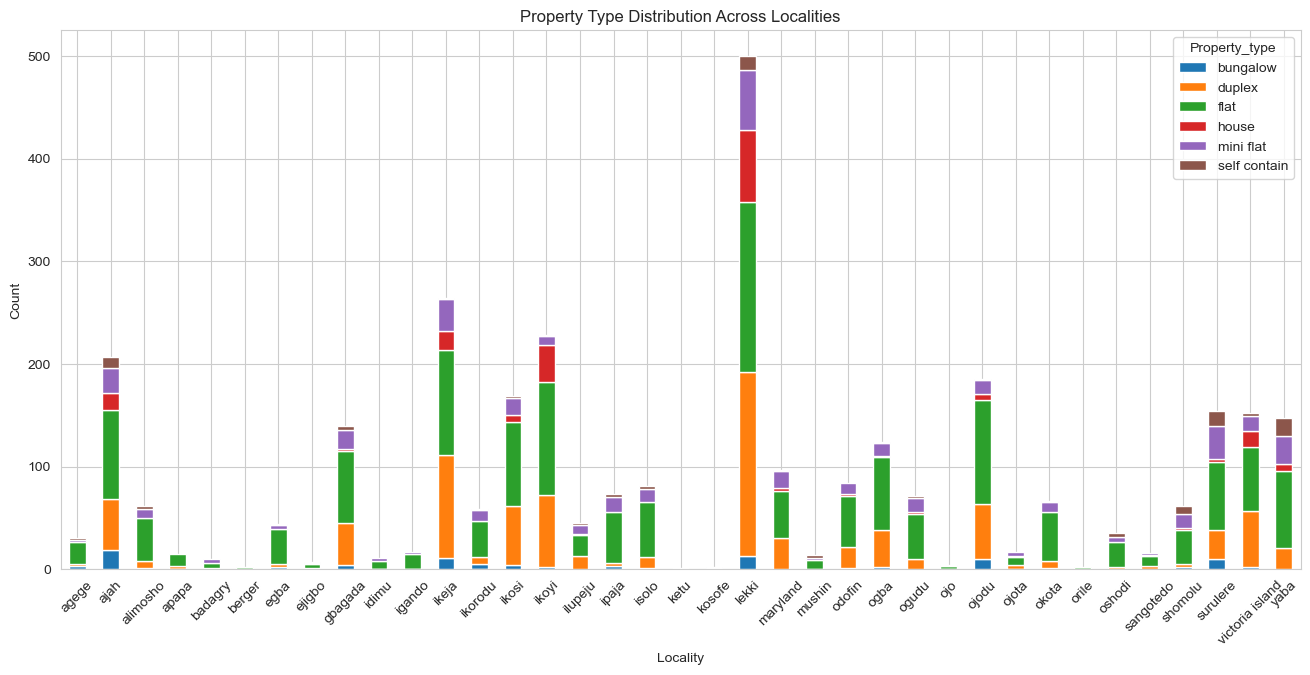

In [131]:
locality_property.plot(
    kind='bar',
    stacked=True,
    figsize=(16,7)
)

plt.title('Property Type Distribution Across Localities')
plt.xlabel('Locality')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

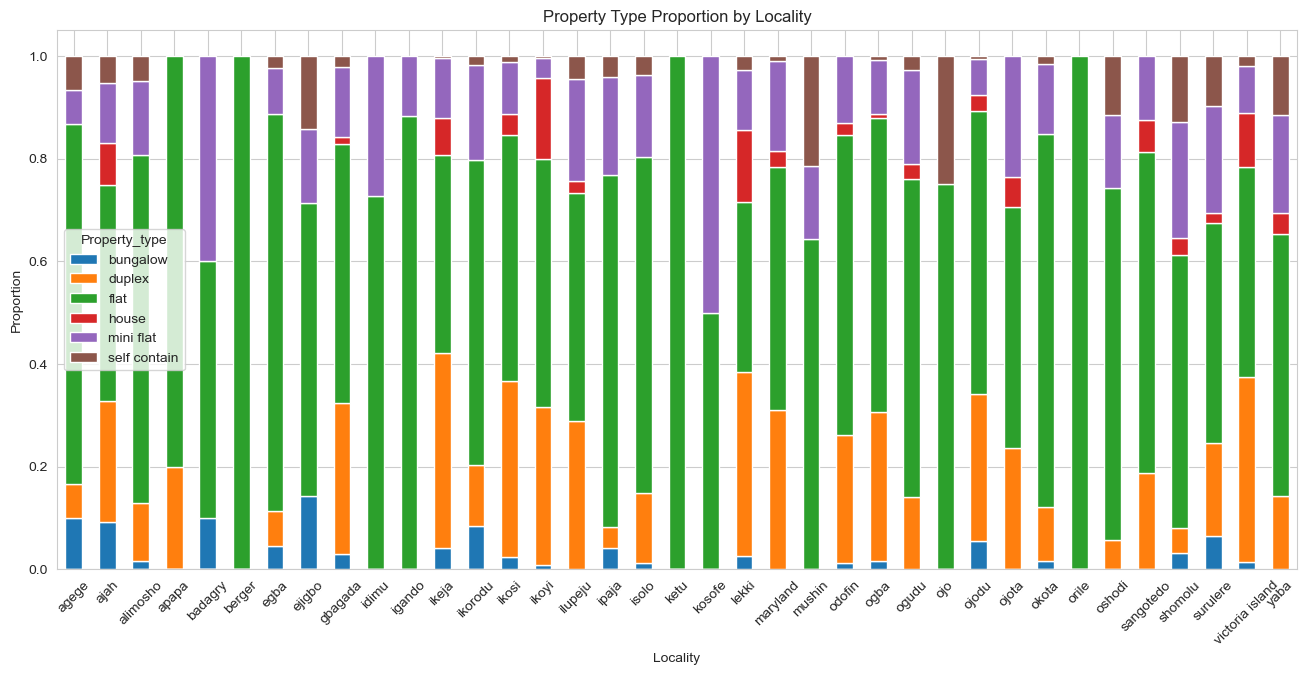

In [133]:
locality_property_pct = pd.crosstab(
    df['Locality'],
    df['Property_type'],
    normalize='index'
)

locality_property_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(16,7)
)

plt.title('Property Type Proportion by Locality')
plt.xlabel('Locality')
plt.ylabel('Proportion')

plt.xticks(rotation=45)

plt.show()

In [135]:
df

,Price,Bedrooms,Locality,Is_premium_subarea,Property_type,Area,Is_estate,Price_log,Group_median,Group_std,Price_zscore_in_group
0,400000,1,ajah,0,mini flat,island,1,12.899222,365000.0,1.204600e+06,0.029055
1,14000000,3,ikoyi,1,flat,island,0,16.454568,7500000.0,5.588542e+06,1.163094
2,200000,1,yaba,0,mini flat,mainland,0,12.206078,350000.0,1.978814e+05,-0.758030
3,800000,2,surulere,0,flat,mainland,0,13.592368,725000.0,3.662361e+05,0.204786
4,300000,1,yaba,0,mini flat,mainland,0,12.611541,350000.0,1.978814e+05,-0.252677
...,...,...,...,...,...,...,...,...,...,...,...
3191,2000000,4,odofin,0,duplex,mainland,0,14.508658,1500000.0,3.231787e+05,1.547132
3192,2500000,4,gbagada,0,house,mainland,0,14.731802,2500000.0,1.000000e+00,0.000000
3193,900000,2,ogudu,1,flat,mainland,0,13.710151,1000000.0,4.179620e+05,-0.239256
3194,3600000,1,ilupeju,0,mini flat,mainland,0,15.096445,400000.0,7.369032e+05,4.342497


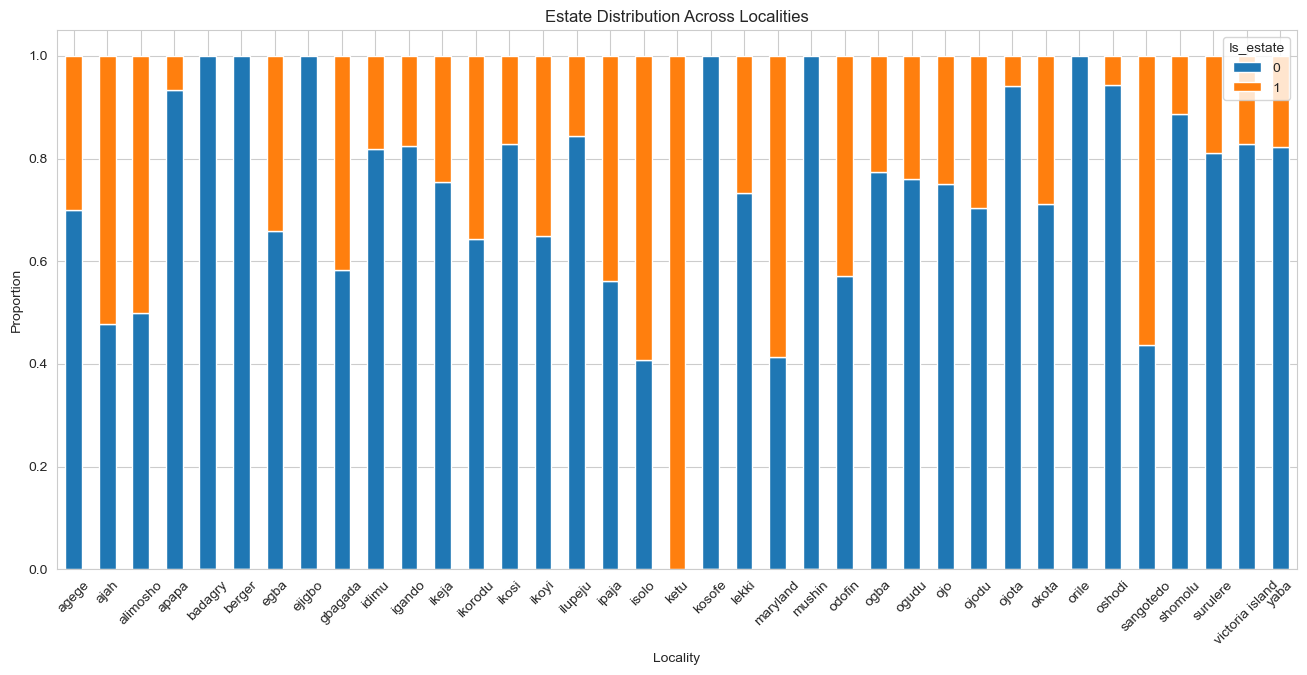

In [137]:
estate_locality = pd.crosstab(
    df['Locality'],
    df['Is_estate'],
    normalize='index'
)

estate_locality.plot(
    kind='bar',
    stacked=True,
    figsize=(16,7)
)

plt.title('Estate Distribution Across Localities')
plt.xlabel('Locality')
plt.ylabel('Proportion')

plt.xticks(rotation=45)

plt.show()

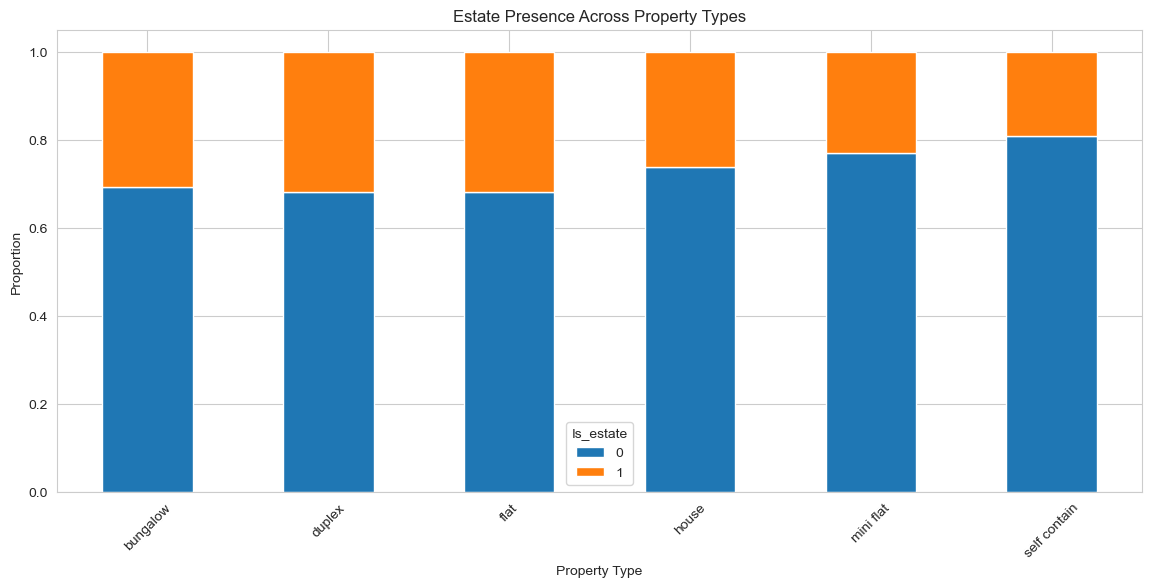

In [143]:
estate_property = pd.crosstab(
    df['Property_type'],
    df['Is_estate'],
    normalize='index'
)

estate_property.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title('Estate Presence Across Property Types')
plt.xlabel('Property Type')
plt.ylabel('Proportion')

plt.xticks(rotation=45)

plt.show()

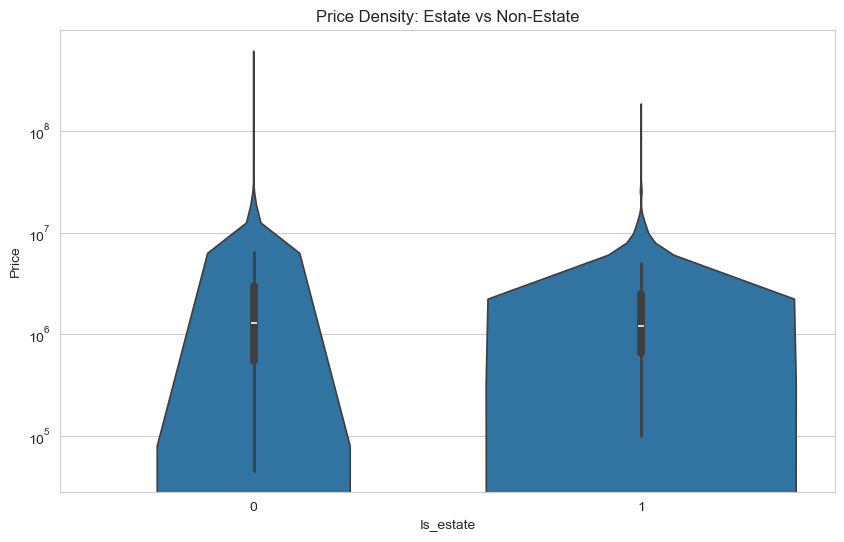

In [145]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Is_estate',
    y='Price'
)

plt.yscale('log')

plt.title('Price Density: Estate vs Non-Estate')
plt.show()

In [147]:
estate_price_summary = (
    df.groupby('Is_estate')['Price']
      .agg(['mean', 'median', 'min', 'max'])
)

print(estate_price_summary)

                   mean     median     min        max
Is_estate                                            
0          3.311576e+06  1300000.0   45000  600000000
1          2.499540e+06  1200000.0  100000  180000000


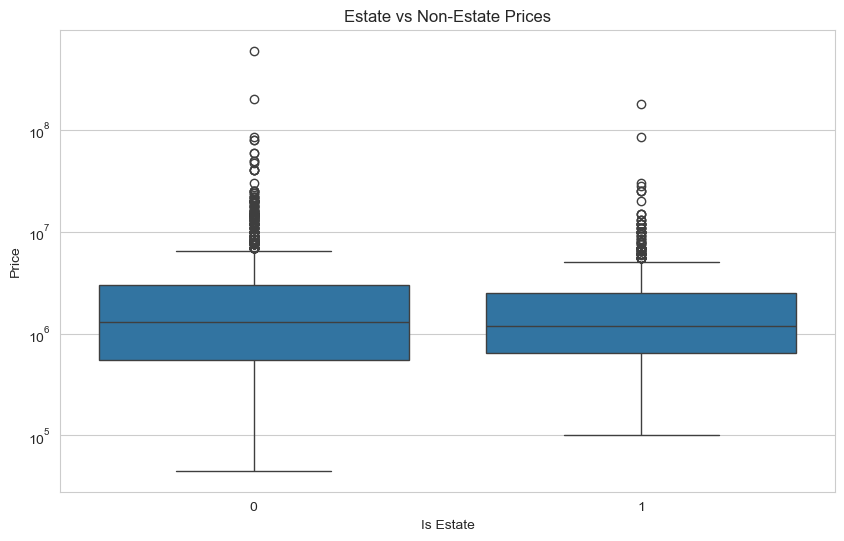

In [149]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Is_estate',
    y='Price'
)

plt.yscale('log')

plt.title('Estate vs Non-Estate Prices')
plt.xlabel('Is Estate')
plt.ylabel('Price')

plt.show()

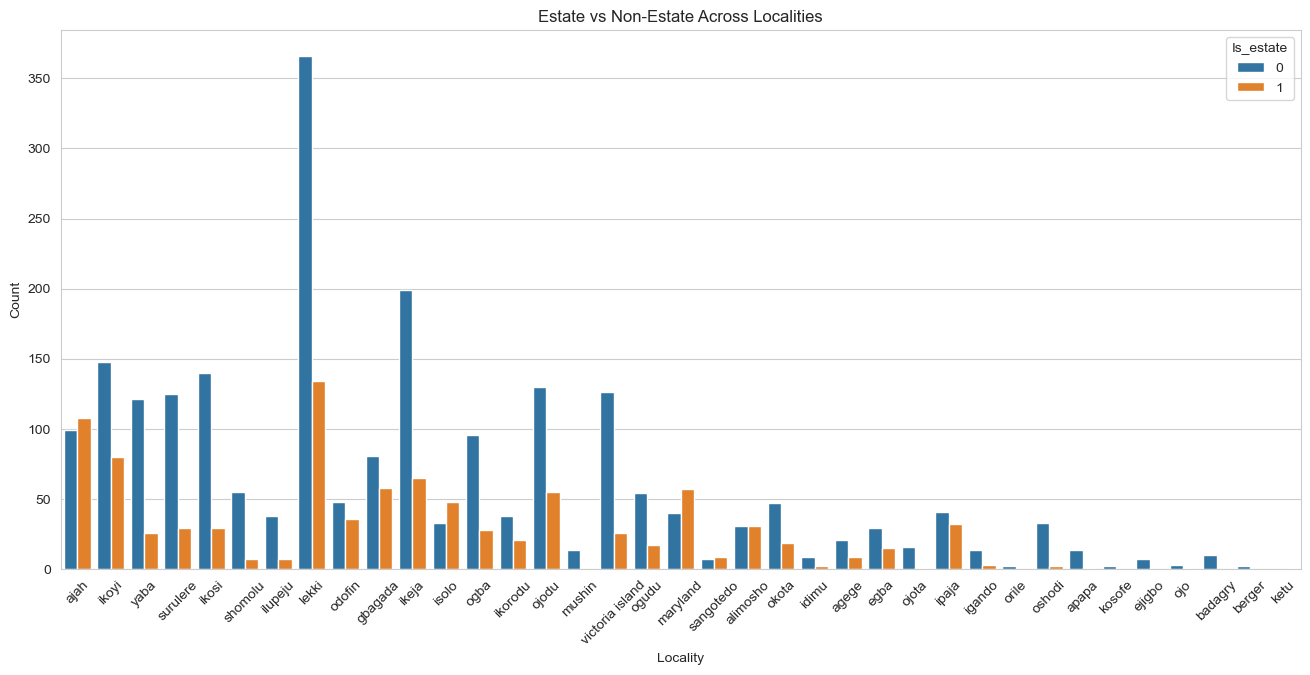

In [139]:
plt.figure(figsize=(16,7))

sns.countplot(
    data=df,
    x='Locality',
    hue='Is_estate'
)

plt.title('Estate vs Non-Estate Across Localities')
plt.xlabel('Locality')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

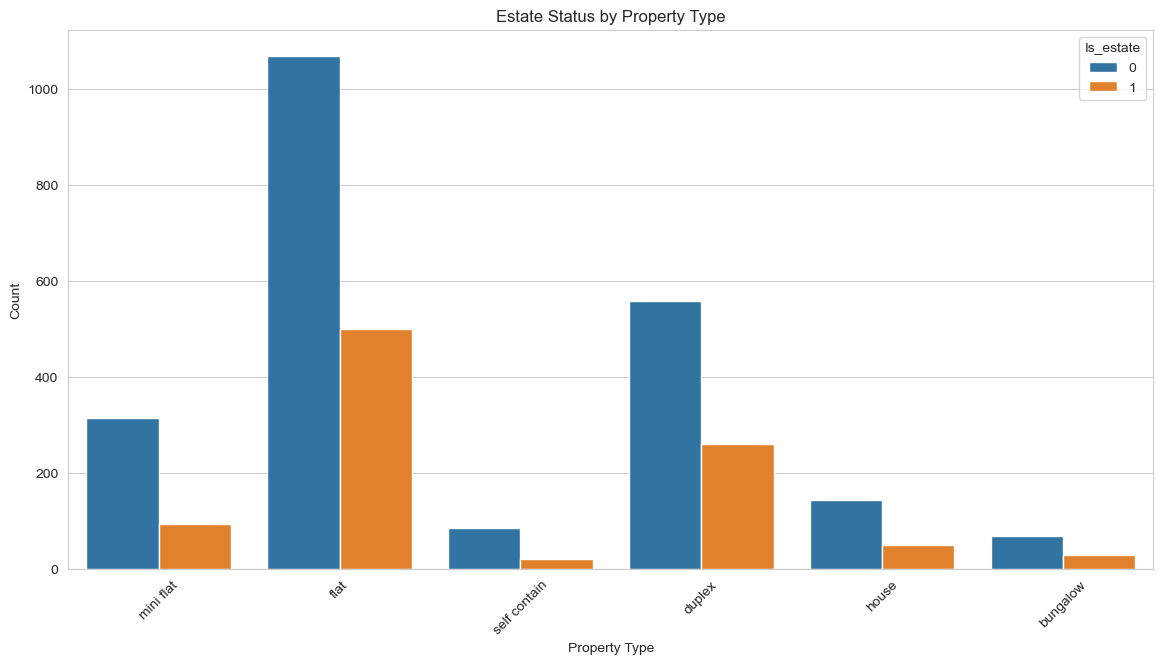

In [141]:
plt.figure(figsize=(14,7))

sns.countplot(
    data=df,
    x='Property_type',
    hue='Is_estate'
)

plt.title('Estate Status by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()